# 07 - The Last Two Features of the List

The ranked list of notebook 05 has two items left.

**Item 3: the stores that came back.** In the first month after a renovated
store reopens, the error was 0.265, twice the level of every later month. The
mechanism is easy to name: our learned store statistics are averages over the
whole training history, and for a store that has just come back they describe
a shop that no longer exists.

**Item 5: the start of the month.** Days 1 to 5 scored 0.178 against 0.116
for days 6 to 10 - the payday effect.

The two items do not deserve the same expectations, and it is fair to write
that down before measuring. The reopening family brings the model something it
truly cannot see today. The month family does not: the model already has the
day of the month as a raw number, and a tree can split on `day <= 5` whenever
that helps. Notebook 03 taught us what usually happens then - a clean pattern
in the error, a reasonable feature, and no gain, because the model knew it
already. We build both anyway, because the list says so and measuring is the
only way to know.

The model we start from is the one notebook 06 left: one XGBoost per segment
with the closed-day family and the Easter distance, at **0.1189**. This
notebook trains it with faster settings, explained below, and measures it
again under them, so that every comparison is between models trained the
same way.


In [1]:
import sys
from datetime import date
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.data_loader import DataLoader
from src.features import (FeatureBuilder, build_closure_calendar,
                          build_reopening_calendar, REOPENING_COLUMNS, MONTH_COLUMNS)
from src.model import SalesModel, DEFAULT_PARAMS
from src.segments import StoreSegmenter
from src.validation import RollingOriginSplit
from src.metrics import rmspe

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
pl.Config.set_tbl_rows(20)

loader = DataLoader(PROJECT_ROOT / "data")
df = loader.load()
calendar = loader.load(drop_closed=False)
folds = list(RollingOriginSplit(n_splits=4).split(df))
print("Open days:", f"{df.height:,}")


Open days: 844,392


## Days since the reopening

`build_reopening_calendar` in `src/features.py` walks each store's calendar
and looks for **long closures**: closed stretches of at least 21 days. The
longest normal closures in this data are holiday blocks of three or four days,
so three weeks cannot be confused with them. The feature counts the days since
the end of the newest long closure, starting at 0 on the first day back and
cut at 365. A day before any long closure, and a store that never had one,
get the cap - for the model they are all simply "not recent".

Notebook 05 found the renovated stores in a cruder way, as the stores with no
rows at all in the second half of 2014. The first check below is that the gap
rule finds every one of them.

Like the closed-day family, none of this is learned from the sales. Which days
a store traded is a fact of the past at prediction time.


In [2]:
reopening = build_reopening_calendar(calendar)

# Notebook 05 found the renovated stores by looking for stores with no rows
# in the second half of 2014. The gap rule should find every one of them.
all_stores = set(df["Store"].unique().to_list())
active_2014_h2 = set(
    df.filter((pl.col("Date") >= date(2014, 7, 1)) & (pl.col("Date") <= date(2014, 12, 31)))
    ["Store"].unique().to_list())
renovated_nb05 = all_stores - active_2014_h2
found = set(reopening.filter(pl.col("days_since_reopening") == 0)["Store"].to_list())
print(f"Stores with no rows in 2014-H2 (notebook 05): {len(renovated_nb05)}")
print(f"Stores with a long closure (the gap rule):    {len(found)}")
print(f"Notebook 05 stores the gap rule misses:       {len(renovated_nb05 - found)}")
print(f"Stores the gap rule finds on top:             {len(found - renovated_nb05)}")

store = sorted(renovated_nb05)[0]
back = (reopening.filter((pl.col("Store") == store)
                         & (pl.col("days_since_reopening") == 0))["Date"].max())
print(f"\nStore {store} came back on {back}:")
print(reopening.filter((pl.col("Store") == store)
                       & (pl.col("Date") >= back - pl.duration(days=2))
                       & (pl.col("Date") <= back + pl.duration(days=3))))

normal = reopening.filter(pl.col("Store") == 1)["days_since_reopening"]
print(f"\nStore 1, never renovated: every value is {normal.min()} (the cap)")


Stores with no rows in 2014-H2 (notebook 05): 180
Stores with a long closure (the gap rule):    199
Notebook 05 stores the gap rule misses:       0
Stores the gap rule finds on top:             19

Store 13 came back on 2015-01-02:
shape: (5, 3)
┌───────┬────────────┬──────────────────────┐
│ Store ┆ Date       ┆ days_since_reopening │
│ ---   ┆ ---        ┆ ---                  │
│ i64   ┆ date       ┆ i64                  │
╞═══════╪════════════╪══════════════════════╡
│ 13    ┆ 2015-01-01 ┆ 365                  │
│ 13    ┆ 2015-01-02 ┆ 0                    │
│ 13    ┆ 2015-01-03 ┆ 1                    │
│ 13    ┆ 2015-01-04 ┆ 2                    │
│ 13    ┆ 2015-01-05 ┆ 3                    │
└───────┴────────────┴──────────────────────┘

Store 1, never renovated: every value is 365 (the cap)


## The statistics learn to forget

The second half of the family does not add a column. It changes how the three
learned store statistics are computed.

`store_mean_sales`, `store_dow_mean_sales` and `store_promo_uplift` are the
strongest features of the model, and for a renovated store they are wrong on
purpose: they average the old shop and the new shop together. So, with
`with_reopening=True`, the builder computes them **from the days after the
reopening only** - for the stores that have at least 60 such days in the
training window. Stores with a shorter new history, and stores that never
closed, keep their statistics exactly as before.

The cell below shows what that changes on the last fold.


In [3]:
prebuilt = build_closure_calendar(calendar).join(reopening, on=["Store", "Date"], how="left")

with_stats = FeatureBuilder(calendar=prebuilt, with_easter=True, with_reopening=True,
                            with_reopening_stats=True).fit(folds[3].train)
without = FeatureBuilder(calendar=prebuilt, with_easter=True).fit(folds[3].train)

changed = (without._store_mean_
           .join(with_stats._store_mean_, on="Store", suffix="_after")
           .with_columns((pl.col("store_mean_sales_after")
                          / pl.col("store_mean_sales") - 1).alias("shift"))
           .filter(pl.col("shift").abs() > 1e-6))
print(f"Stores whose learned mean changed: {changed.height}")
print(f"Middle shift: {100 * changed['shift'].median():+.1f}% "
      f"(negative = the old average was too high)")
print()
print(changed.sort("shift").select(["Store", "store_mean_sales",
                                    "store_mean_sales_after", "shift"]).head(5))


Stores whose learned mean changed: 196
Middle shift: +3.4% (negative = the old average was too high)

shape: (5, 4)
┌───────┬──────────────────┬────────────────────────┬───────────┐
│ Store ┆ store_mean_sales ┆ store_mean_sales_after ┆ shift     │
│ ---   ┆ ---              ┆ ---                    ┆ ---       │
│ i64   ┆ f64              ┆ f64                    ┆ f64       │
╞═══════╪══════════════════╪════════════════════════╪═══════════╡
│ 815   ┆ 8522.385666      ┆ 6365.144928            ┆ -0.253126 │
│ 629   ┆ 7740.520478      ┆ 6229.434783            ┆ -0.195218 │
│ 113   ┆ 7284.192833      ┆ 6000.188406            ┆ -0.176273 │
│ 52    ┆ 7458.116041      ┆ 6625.152174            ┆ -0.111686 │
│ 677   ┆ 7996.387372      ┆ 7107.862319            ┆ -0.111116 │
└───────┴──────────────────┴────────────────────────┴───────────┘


## The start of the month

Two columns, both from the date alone: `month_start` marks days 1 to 5, and
`days_to_month_end` counts down to the month's last day, so that the end of
the month is a place too and not only a large day number.


In [4]:
sample = FeatureBuilder(with_month=True).fit(folds[0].train).transform(
    df.filter(pl.col("Store") == 1))
print(sample.filter(pl.col("Date").is_in(
    [date(2015, 1, 1), date(2015, 1, 3), date(2015, 1, 6),
     date(2015, 1, 31), date(2015, 2, 28)]))
    .select(["Date", "month_start", "days_to_month_end"]))


shape: (4, 3)
┌────────────┬─────────────┬───────────────────┐
│ Date       ┆ month_start ┆ days_to_month_end │
│ ---        ┆ ---         ┆ ---               │
│ date       ┆ i8          ┆ i32               │
╞════════════╪═════════════╪═══════════════════╡
│ 2015-01-03 ┆ 1           ┆ 28                │
│ 2015-01-06 ┆ 0           ┆ 25                │
│ 2015-01-31 ┆ 0           ┆ 0                 │
│ 2015-02-28 ┆ 0           ┆ 0                 │
└────────────┴─────────────┴───────────────────┘


## The experiment

Four arms this time: the base model of notebook 06, the reopening column
alone, the column together with the rewritten statistics, and the month
columns. The reopening idea is split in two on purpose - if it fails, we want
to know which half failed.

The protocol changes here, and the change deserves a sentence. Notebook 06 ran
three seeds for every arm. That is the right price to *accept* a feature, but
it is a high price to reject one: if a column is not better on the four
windows with one seed, two more seeds will not save it. So from now on we
**screen with one seed and confirm with three**. The base runs with three
seeds, which tells us the seed noise. Every other arm runs with one seed and
is compared against the base on every window. Only an arm that beats the base
on all four windows by more than the seed noise gets the two other seeds, and
nothing is accepted before that. The bar itself is unchanged.

Two settings make each round cheaper without changing the model: a learning
rate of 0.1 instead of 0.05, which needs about half the trees, and 128 bins
per feature. The base is measured again under these settings, so every arm is
compared with a model trained exactly the same way.

In [5]:
SEGMENTS = [1, 2, 3, 4]
SEEDS = [42, 7, 2024]

# The model of notebook 06, trained faster. eta 0.1 needs about half the
# trees of 0.05, and 128 bins per feature make every tree cheaper to build.
PARAMS = dict(DEFAULT_PARAMS, eta=0.1, max_bin=128)

# Every arm keeps the whole model of notebook 06 and adds one thing. The
# reopening family is tested in two steps, so that if it fails we know
# which half failed: the column, or the rewritten statistics.
BASE = "base (nb 06)"
ARMS = {
    "+ reopening column": dict(with_reopening=True),
    "+ column + statistics": dict(with_reopening=True, with_reopening_stats=True),
    "+ month": dict(with_month=True),
}


def fit_predict(flags, seed, fold, rounds=None):
    """Train the four segment models on one window and score it.

    `rounds` holds the tree count per segment from an earlier seed. When it
    is given, the inner window is skipped and the count is reused.
    """
    builder = FeatureBuilder(calendar=prebuilt, with_easter=True, **flags).fit(fold.train)
    segmenter = StoreSegmenter(n_segments=4).fit(fold.train)
    tr = segmenter.transform(builder.transform(fold.train))
    va = segmenter.transform(builder.transform(fold.valid))
    parts, used = [], {}
    for s in SEGMENTS:
        tr_s, va_s = tr.filter(pl.col("segment") == s), va.filter(pl.col("segment") == s)
        if va_s.height == 0:
            continue
        model = SalesModel(params=dict(PARAMS, seed=seed),
                           fixed_rounds=None if rounds is None else rounds[s])
        model.fit(tr_s, builder.feature_names_)
        used[s] = model.best_rounds_
        parts.append(va_s.with_columns(pl.Series("prediction", model.predict(va_s))))
    return pl.concat(parts), used

In [6]:
# The base with three seeds, every other arm with one. An arm that is not
# better on every window by more than the seed noise is rejected here. An
# arm that passes gets the two other seeds before anything is decided.
import time

scores, kept, rounds = {}, {}, {}


def run(name, flags, seeds):
    grid = np.zeros((len(seeds), len(folds)))
    for i, seed in enumerate(seeds):
        for j, fold in enumerate(folds):
            out, used = fit_predict(flags, seed, fold, rounds.get((name, j)))
            rounds.setdefault((name, j), used)
            grid[i, j] = rmspe(out["Sales"], out["prediction"])
            kept.setdefault(name, []).append(
                out.select(["Store", "Date", "Sales", "prediction"])
                .with_columns(pl.lit(fold.index).alias("fold"),
                              pl.lit(seed).alias("seed")))
    return grid


started = time.perf_counter()
scores[BASE] = run(BASE, {}, SEEDS)
base = scores[BASE].mean(axis=0)
noise = scores[BASE].mean(axis=1).std()
print(f"{BASE:<24} " + " ".join(f"{v:.4f}" for v in base)
      + f"   mean={base.mean():.4f}  seed noise={noise:.4f}  ({len(SEEDS)} seeds)")

for name, flags in ARMS.items():
    grid = run(name, flags, SEEDS[:1])
    passed = bool(((grid.mean(axis=0) - base) < -noise).all())
    if passed:
        grid = np.vstack([grid, run(name, flags, SEEDS[1:])])
    scores[name] = grid
    print(f"{name:<24} " + " ".join(f"{v:.4f}" for v in grid.mean(axis=0))
          + f"   mean={grid.mean():.4f}  "
          + ("confirmed with 3 seeds" if passed else "rejected at 1 seed"))

kept = {name: pl.concat(parts) for name, parts in kept.items()}
print()
print(f"{time.perf_counter() - started:.0f} seconds")

base (nb 06)             0.1666 0.1022 0.1031 0.1122   mean=0.1210  seed noise=0.0008  (3 seeds)


+ reopening column       0.1716 0.1020 0.1014 0.1129   mean=0.1220  rejected at 1 seed


+ column + statistics    0.1770 0.1011 0.1014 0.1144   mean=0.1235  rejected at 1 seed


+ month                  0.1676 0.1039 0.1027 0.1103   mean=0.1211  rejected at 1 seed

854 seconds


In [7]:
print("Against the base. A negative number means the arm is better.")
for name, grid in scores.items():
    if name == BASE:
        continue
    delta = grid.mean(axis=0) - base
    print(f"  {name:<22} " + " ".join(f"{v:+.4f}" for v in delta)
          + f"   mean {grid.mean() - base.mean():+.4f}   better on {int((delta < 0).sum())}/4")

Against the base. A negative number means the arm is better.
  + reopening column     +0.0050 -0.0003 -0.0017 +0.0006   mean +0.0009   better on 2/4
  + column + statistics  +0.0104 -0.0012 -0.0017 +0.0022   mean +0.0024   better on 2/4
  + month                +0.0010 +0.0017 -0.0004 -0.0020   mean +0.0001   better on 2/4


**Both families are rejected**, and the ablation says something better than a
plain no.

First the base. Under the faster settings it scores 0.1210 against 0.1189 in
notebook 06, so the higher learning rate costs about 0.002. That is the price
of a run that takes a quarter of an hour instead of an hour, and step 8 will
set the learning rate properly anyway. Inside this notebook every arm pays the
same price, so the comparison is fair. The seed noise of the base is 0.0008.

The month family lands at 0.1211, the same as the base to the third decimal,
better on two windows and worse on two, every difference inside the noise.
This is the outcome we pre-registered: the model already has the day of the
month, so the two new columns brought no new information. Notebook 03,
again.

The reopening story is more interesting. The column alone is worse by
0.0009 on average, and the average hides the shape: two small wins on the
middle windows and a loss of 0.0050 on the oldest window, six times the seed
noise. The rewritten statistics make the same shape larger - a loss of
0.0104 on the oldest window, and 0.0024 on average. The oldest window is the
one where the reopened stores have the shortest new history: only a few
weeks of small `days_since_reopening` values, and a few weeks of new sales
to average. Whatever the model learns from those few weeks does not carry
into the validation days, and an average over a few weeks is a noisy
average. So both halves of the family fail, and for the same reason: too
little history behind the new information.

In [8]:
# Where does the reopening family act? The error of the recently reopened
# rows, before and after, averaged over the seeds.
def by_bucket(name):
    per_seed = (kept[name]
                .join(reopening, on=["Store", "Date"], how="left")
                .filter(pl.col("Sales") != 0)
                .with_columns(
                    (pl.col("days_since_reopening") // 30 * 30).clip(upper_bound=180)
                    .alias("bucket"),
                    (((pl.col("Sales") - pl.col("prediction")) / pl.col("Sales")) ** 2)
                    .alias("sq"))
                .group_by(["bucket", "seed"])
                .agg(pl.col("sq").mean().sqrt().alias("_r"), pl.len().alias("rows")))
    return (per_seed.group_by("bucket")
            .agg(pl.col("_r").mean().round(4).alias(name),
                 pl.col("rows").mean().cast(pl.Int64).alias("rows")).sort("bucket"))


table = (by_bucket(BASE)
         .join(by_bucket("+ reopening column").drop("rows"), on="bucket")
         .join(by_bucket("+ column + statistics").drop("rows"), on="bucket"))
print("Days since the reopening, in blocks of 30. 180 holds every later day")
print("and every store that never closed for long.")
print(table)


Days since the reopening, in blocks of 30. 180 holds every later day
and every store that never closed for long.
shape: (7, 5)
┌────────┬──────────────┬────────┬────────────────────┬───────────────────────┐
│ bucket ┆ base (nb 06) ┆ rows   ┆ + reopening column ┆ + column + statistics │
│ ---    ┆ ---          ┆ ---    ┆ ---                ┆ ---                   │
│ i64    ┆ f64          ┆ i64    ┆ f64                ┆ f64                   │
╞════════╪══════════════╪════════╪════════════════════╪═══════════════════════╡
│ 0      ┆ 0.3095       ┆ 47     ┆ 0.2796             ┆ 0.2621                │
│ 30     ┆ 0.2427       ┆ 2561   ┆ 0.2499             ┆ 0.2634                │
│ 60     ┆ 0.1136       ┆ 4706   ┆ 0.1188             ┆ 0.1254                │
│ 90     ┆ 0.0966       ┆ 4176   ┆ 0.1012             ┆ 0.0973                │
│ 120    ┆ 0.1074       ┆ 4156   ┆ 0.106              ┆ 0.1027                │
│ 150    ┆ 0.1171       ┆ 4493   ┆ 0.1154             ┆ 0.1117           

The bucket table shows where the family acts, and why the whole is a loss.

The column does what it was built for, but only in the first thirty days:
the first bucket drops from 0.310 to 0.280, and to 0.262 with the rewritten
statistics. That bucket holds 47 rows. From day 30 on, every bucket is worse
than the base, and so is the last one - the 134,834 rows of the stores that
never closed for long, where the column is a constant and should change
nothing. It changes something anyway. Each tree draws 80 percent of the
columns, and a column that carries no information for 97 percent of the
rows is one more way to draw a slightly worse tree.

So the problem that notebook 05 found is real and it is still there: the
first two months after a reopening score 0.31 and 0.24 against 0.11 later.
But it lives on about 2,600 of 150,000 rows, and a column that improves 47
of them and disturbs the rest cannot pay for itself. A narrow problem needs a
narrow fix, and a feature that every tree can see is not narrow.

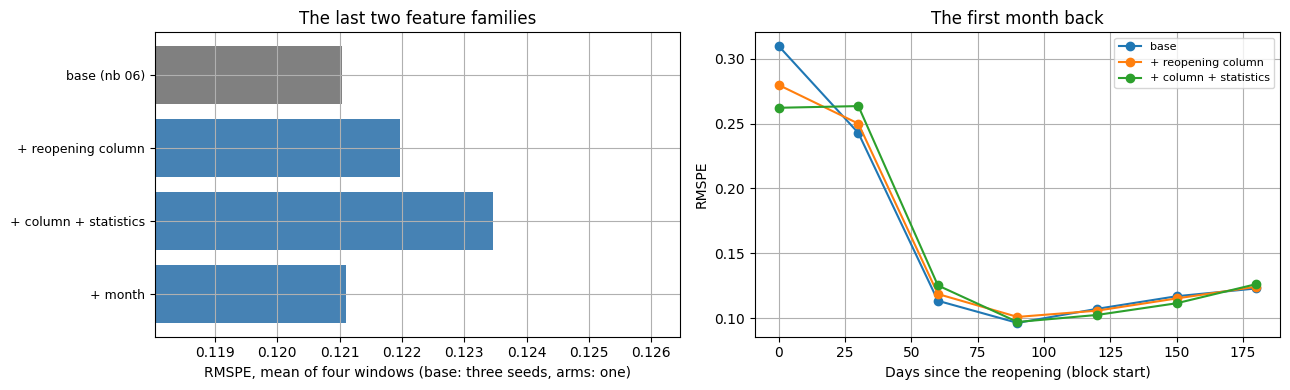

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order = list(scores)
means = [scores[n].mean() for n in order]
colors = ["gray"] + ["steelblue"] * (len(order) - 1)
axes[0].barh(range(len(order)), means, color=colors)
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels(order, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlim(min(means) - 0.003, max(means) + 0.003)
axes[0].set_xlabel("RMSPE, mean of four windows (base: three seeds, arms: one)")
axes[0].set_title("The last two feature families")

buckets = table["bucket"].to_list()
axes[1].plot(buckets, table[BASE].to_list(), marker="o", label="base")
axes[1].plot(buckets, table["+ reopening column"].to_list(), marker="o",
             label="+ reopening column")
axes[1].plot(buckets, table["+ column + statistics"].to_list(), marker="o",
             label="+ column + statistics")
axes[1].set_xlabel("Days since the reopening (block start)")
axes[1].set_ylabel("RMSPE")
axes[1].set_title("The first month back")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Key findings

1. **Both families are rejected.** The reopening column gives 0.1220, the
   column with the rewritten statistics 0.1235, and the month columns
   0.1211, against 0.1210 for the base measured the same way. None is
   better on every window; the reopening family loses most on the oldest
   window, by six and thirteen times the seed noise. The model keeps the
   feature set of notebook 06.
2. **The ablation pins the reopening failure on history, not on one half.**
   The column alone already loses on the oldest window, where the reopened
   stores have only a few weeks of new history, and the rewritten
   statistics double the loss for the same reason - a few weeks make a noisy
   average.
3. **The column works where it aims and costs everywhere else.** The first
   month back improves from 0.31 to 0.28, on 47 rows. Every later bucket is
   worse, including the 134,834 rows of stores that never closed for long.
   The renovation problem is real, but it is too narrow for a feature that
   every tree can see.
4. **The month family failed exactly as pre-registered.** The model already
   has the day of the month; the flag and the countdown were the same
   information in new clothes, and the score did not move.
5. **Screening is enough to reject.** One seed on four windows said no to
   all three arms; three seeds would have said the same, at three times the
   price. The base still runs with three seeds, which is where the seed
   noise comes from.

Step 7 of the plan is now closed. Four ideas from the error analysis were
built and measured: the closed-day family and the Easter distance are in the
model (0.1451 to 0.1189), the reopening and month families are tested and
rejected. Rejections are results too - both columns stay in `src/features.py`
behind their flags, with this notebook as the record of why they are off.

### What this means for the plan

What remains is step 8, a modest hyperparameter search, and step 9, the
calibration of the small downward bias. The search has one more reason to
exist now: the faster settings of this notebook cost 0.002, and the learning
rate deserves a proper choice rather than a guess.